In [276]:
import numpy as num
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Project: Renewable Energy Contribution Analysis


Problem Statement:
Can solar and wind generation meet electricity demand throughout the day?

In [277]:
renwable_demand=pd.read_excel("re_data.xlsx")
renwable_demand

,Hour,Time,Solar_GW,Wind_GW,Demand_GW,Period
0,0,00:00,0.0,2.8,155,Non-solar
1,1,01:00,0.0,2.7,150,Non-solar
2,2,02:00,0.0,2.7,145,Non-solar
3,3,03:00,0.0,2.8,143,Non-solar
4,4,04:00,0.0,2.9,142,Non-solar
5,5,05:00,0.0,3.0,148,Non-solar
6,6,06:00,0.5,3.1,162,Non-solar
7,7,07:00,3.2,3.2,175,Solar
8,8,08:00,8.5,3.3,188,Solar
9,9,09:00,13.4,3.4,198,Solar


In [278]:
renwable_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Hour       24 non-null     int64  
 1   Time       24 non-null     str    
 2   Solar_GW   24 non-null     float64
 3   Wind_GW    24 non-null     float64
 4   Demand_GW  24 non-null     int64  
 5   Period     24 non-null     str    
dtypes: float64(2), int64(2), str(2)
memory usage: 1.3 KB


In [279]:
solar_power=renwable_demand.groupby("Period")["Solar_GW"].mean().reset_index()
wind_power=renwable_demand.groupby("Period")["Wind_GW"].mean().reset_index()


In [280]:
max_solar=solar_power.loc[solar_power["Solar_GW"]==solar_power["Solar_GW"].max()]
max_solar["Period"].values[0]
max_wind=wind_power.loc[wind_power["Wind_GW"]==wind_power["Wind_GW"].max()]
max_wind["Period"].values[0]

'Solar'

In [281]:
renwable_demand["RE_GW"]=renwable_demand["Solar_GW"]+renwable_demand["Wind_GW"]
renwable_demand["Conventional_GW"]=renwable_demand["Demand_GW"]-renwable_demand["RE_GW"]


Text(0, 0.5, 'Power Demand')

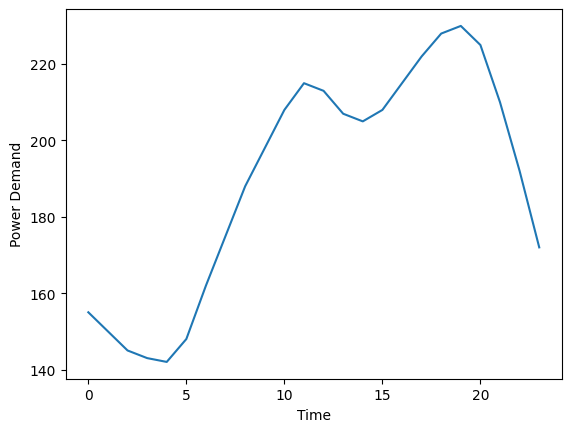

In [282]:
plt.plot(renwable_demand["Hour"],renwable_demand["Demand_GW"])
plt.xlabel("Time")
plt.ylabel("Power Demand")

Text(0, 0.5, 'Wind Power')

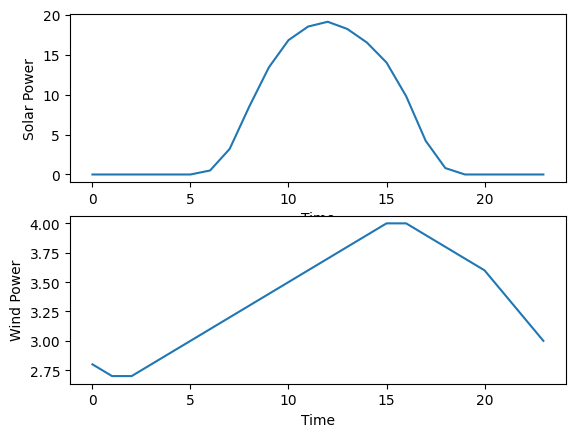

In [283]:
plt.Figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(renwable_demand["Hour"],renwable_demand["Solar_GW"])
plt.xlabel("Time")
plt.ylabel("Solar Power")

plt.subplot(2,1,2)
plt.plot(renwable_demand["Hour"],renwable_demand["Wind_GW"])
plt.xlabel("Time")
plt.ylabel("Wind Power")
# plt.subplot(1,3,3)
# plt.plot(renwable_demand["Hour"],renwable_demand["Total_RE"])


Text(0, 0.5, 'Conventional Power')

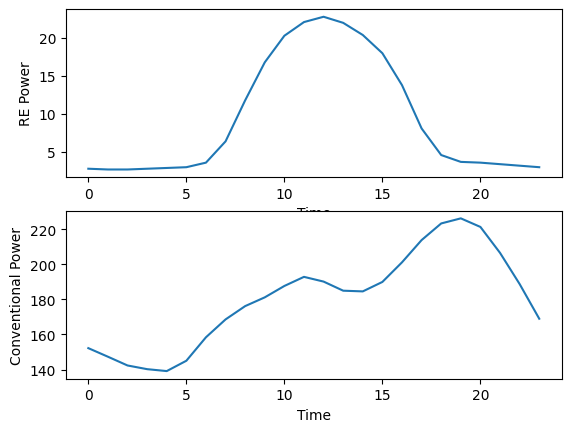

In [284]:
plt.subplot(2,1,1)
plt.plot(renwable_demand["Hour"],renwable_demand["RE_GW"])
plt.xlabel("Time")
plt.ylabel("RE Power")
plt.subplot(2,1,2)
plt.plot(renwable_demand["Hour"],renwable_demand["Conventional_GW"])
plt.xlabel("Time")
plt.ylabel("Conventional Power")

In [285]:
renwable_demand["RE_Share"]=(renwable_demand["RE_GW"]/renwable_demand["Demand_GW"])*100
renwable_demand["Conventional_Share"]=(renwable_demand["Conventional_GW"]/renwable_demand["Demand_GW"])*100



renwable_demand

,Hour,Time,Solar_GW,Wind_GW,Demand_GW,Period,RE_GW,Conventional_GW,RE_Share,Conventional_Share
0,0,00:00,0.0,2.8,155,Non-solar,2.8,152.2,1.806452,98.193548
1,1,01:00,0.0,2.7,150,Non-solar,2.7,147.3,1.800000,98.200000
2,2,02:00,0.0,2.7,145,Non-solar,2.7,142.3,1.862069,98.137931
3,3,03:00,0.0,2.8,143,Non-solar,2.8,140.2,1.958042,98.041958
4,4,04:00,0.0,2.9,142,Non-solar,2.9,139.1,2.042254,97.957746
5,5,05:00,0.0,3.0,148,Non-solar,3.0,145.0,2.027027,97.972973
6,6,06:00,0.5,3.1,162,Non-solar,3.6,158.4,2.222222,97.777778
7,7,07:00,3.2,3.2,175,Solar,6.4,168.6,3.657143,96.342857
8,8,08:00,8.5,3.3,188,Solar,11.8,176.2,6.276596,93.723404
9,9,09:00,13.4,3.4,198,Solar,16.8,181.2,8.484848,91.515152


Text(0.5, 1.0, ' Total Renwable Power Distribution On Different Period')

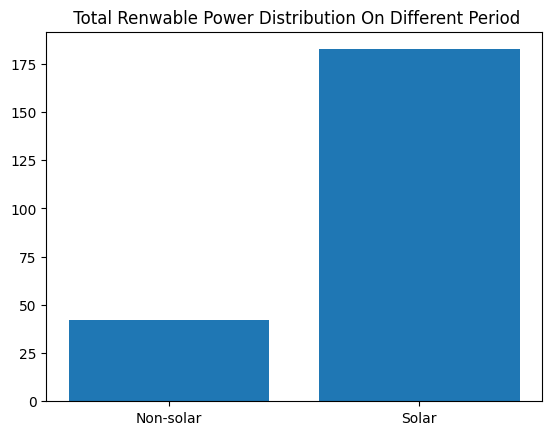

In [286]:
RE_Power=renwable_demand.groupby("Period")["RE_GW"].sum().reset_index()
# RE_Power.plot(kind="bar")
plt.bar(RE_Power["Period"],RE_Power["RE_GW"])
plt.title(" Total Renwable Power Distribution On Different Period")


Text(0.5, 1.0, 'Power Distribution In Whole Day')

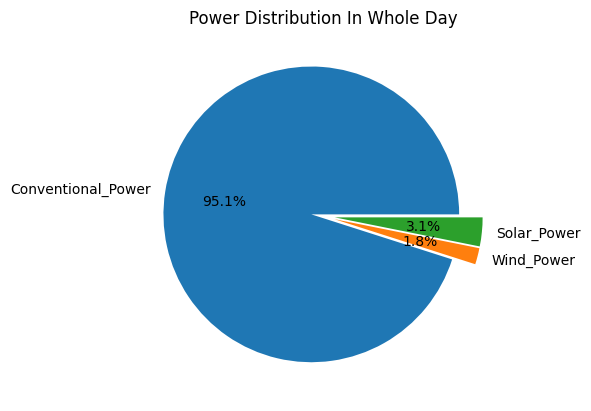

In [287]:

Total_renwable_demand=renwable_demand["Demand_GW"].sum()
Conventional_Total=renwable_demand["Conventional_GW"].sum()
Wind_Total=renwable_demand["Wind_GW"].sum()
Solar_Total=renwable_demand["Solar_GW"].sum()
RE_Total=Wind_Total+Solar_Total
RE_Total_Share=(RE_Total/Total_renwable_demand)*100
Conventional_Total_Share=(Conventional_Total/Total_renwable_demand)*100
plt.pie([Conventional_Total,Wind_Total,Solar_Total],labels=["Conventional_Power","Wind_Power","Solar_Power"],autopct="%0.1f%%",explode=[0.08,0.08,0.08])
plt.title("Power Distribution In Whole Day")

Text(0.5, 1.0, 'Power Distribution in Peak Demand Time')

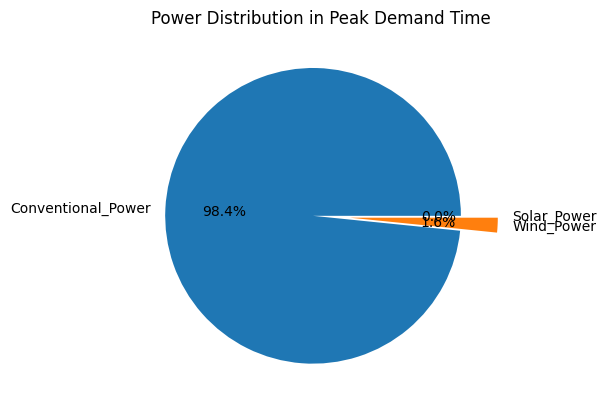

In [288]:
max_period=renwable_demand.loc[renwable_demand["Demand_GW"]==renwable_demand["Demand_GW"].max()]
max_period
Total_Conventional=max_period["Conventional_GW"].sum()
Wind_GW=max_period["Wind_GW"].sum()
Solar_GW=max_period["Solar_GW"].sum()
plt.pie([Total_Conventional,Wind_GW,Solar_GW],labels=["Conventional_Power","Wind_Power","Solar_Power"],autopct="%0.1f%%",explode=[0.05,0.2,0.2])
plt.title("Power Distribution in Peak Demand Time")

Conclusion:

In [289]:
print("Maximum Electricity Demand During Day :",renwable_demand["Demand_GW"].max(),"GW")
max_period=renwable_demand.loc[renwable_demand["Demand_GW"]==renwable_demand["Demand_GW"].max()]
print("Peak Demand Time:",max_period["Time"].values[0])
print("Solar Power in Peak Demand Time:",max_period["Solar_GW"].values[0],"GW")
print("Wind Power in Peak Demand Time:",max_period["Wind_GW"].values[0],"GW")
print("Max Solar Genereation:",renwable_demand["Solar_GW"].max(),"GW")
max_solar_period=renwable_demand.loc[renwable_demand["Solar_GW"]==renwable_demand["Solar_GW"].max()]
print("Max Solar Genereation Time:",max_solar_period["Time"].values[0])
print("Solar Contribution Increases During",max_solar["Period"].values[0],"Period")

max_Wind_period=renwable_demand.loc[renwable_demand["Wind_GW"]==renwable_demand["Wind_GW"].max()]
print("Max Wind Genereation:",renwable_demand["Wind_GW"].max(),"GW")
print("Max Wind Genereation Time:",max_Wind_period["Time"].values[0])
print("Wind Contribution Increases During",max_wind["Period"].values[0],"Period")

print("Total Renwalable Generation",renwable_demand["RE_GW"].sum(),"GW")
print("Total Demand ",renwable_demand["Demand_GW"].sum(),"GW")
print("Total Conventioanl Genereation",renwable_demand["Conventional_GW"].sum(),"GW")
renwable_demand["RE_Share"]=(renwable_demand["RE_GW"]/renwable_demand["Demand_GW"])*100
print("Renewable Energy Contributes up to",round(max_period["RE_Share"].values[0],2),"Percentage of demand In peak Time")
print("Renewable Energy Contributes up to",round(RE_Total_Share,2),"Percentage of demand In whole Day")
print("Conventional Energy Contributes up to",round(max_period["Conventional_Share"].values[0],2),"Percentage of demand In peak Time")
print("Conventional Energy Contributes up to",round(Conventional_Total_Share,2),"Percentage of demand In whole Day")

Maximum Electricity Demand During Day : 230 GW
Peak Demand Time: 19:00
Solar Power in Peak Demand Time: 0.0 GW
Wind Power in Peak Demand Time: 3.7 GW
Max Solar Genereation: 19.1 GW
Max Solar Genereation Time: 12:00
Solar Contribution Increases During Solar Period
Max Wind Genereation: 4.0 GW
Max Wind Genereation Time: 15:00
Wind Contribution Increases During Solar Period
Total Renwalable Generation 224.5 GW
Total Demand  4556 GW
Total Conventioanl Genereation 4331.5 GW
Renewable Energy Contributes up to 1.61 Percentage of demand In peak Time
Renewable Energy Contributes up to 4.93 Percentage of demand In whole Day
Conventional Energy Contributes up to 98.39 Percentage of demand In peak Time
Conventional Energy Contributes up to 95.07 Percentage of demand In whole Day


Day vs Night Demand Analysis

In [290]:
Demand=renwable_demand.groupby("Period")[
    ["Solar_GW", "Wind_GW", "Demand_GW"]
].mean().reset_index()
# print("Average demand during solar period",Demand)
Demand_period=Demand[Demand["Demand_GW"]==Demand["Demand_GW"].max()]


print("The period when load Demand is max:",Demand_period["Period"].values[0])
print("Average demand during solar period",round(Demand_period["Demand_GW"].values[0],2),"GW")


The period when load Demand is max: Solar
Average demand during solar period 204.91 GW
